## Research Questions

In this project, we try to answer:

1. Do US and Indian markets move together in the long run?  
2. Does the US market affect the Indian market in the short run?  
3. Do global macro-financial factors (VIX, BRENT, DXY) influence US and Indian equity markets in the short run?
4. How quickly does India absorb shocks from the US market?
5. Does India react differently to US market rises vs crashes?
6. Does relationship change in the Israel & USA vs Iran War?

### Imports

In [1]:
import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import VECM
import statsmodels.api as sm

### Configuration

In [2]:
import sys
sys.path.append('../')

In [3]:
from src.fetch_data import fetch_data
from src.adf_test import run_adf_test
from src.returns import transform_to_returns
from src.johansen_test import cointegration_test
from src.granger_test import granger_test
from src.irf_plot import plot_irf_relationship
from src.plot_asymmetric import plot_asymmetric_response

### Load Data

In [4]:
data = fetch_data()
data.head()

,SP500,NIFTY,USDINR,VIX,BRENT,DXY
Date,,,,,,
2007-09-17,1476.650024,4494.649902,40.376999,26.480000,76.980003,79.720001
2007-09-18,1519.780029,4546.200195,40.216999,20.350000,77.589996,79.209999
2007-09-19,1529.030029,4732.350098,40.033001,20.030001,78.470001,79.300003
2007-09-20,1518.750000,4747.549805,39.615002,20.450001,79.089996,78.580002
2007-09-21,1525.750000,4837.549805,39.770000,19.000000,79.300003,78.599998


In [5]:
data.tail()

,SP500,NIFTY,USDINR,VIX,BRENT,DXY
Date,,,,,,
2026-03-24,6556.370117,22912.400391,93.243698,26.950001,104.489998,99.430000
2026-03-25,6591.899902,23306.449219,94.299698,25.330000,102.220001,99.599998
2026-03-26,6477.160156,23306.449219,94.693703,27.440001,108.010002,99.900002
2026-03-27,6368.850098,22819.599609,94.309502,31.049999,112.570000,100.150002
2026-03-30,6343.720215,22331.400391,94.781799,30.610001,112.779999,100.510002


## Research Objective – 1
#### Do US and Indian markets move together in the long run?

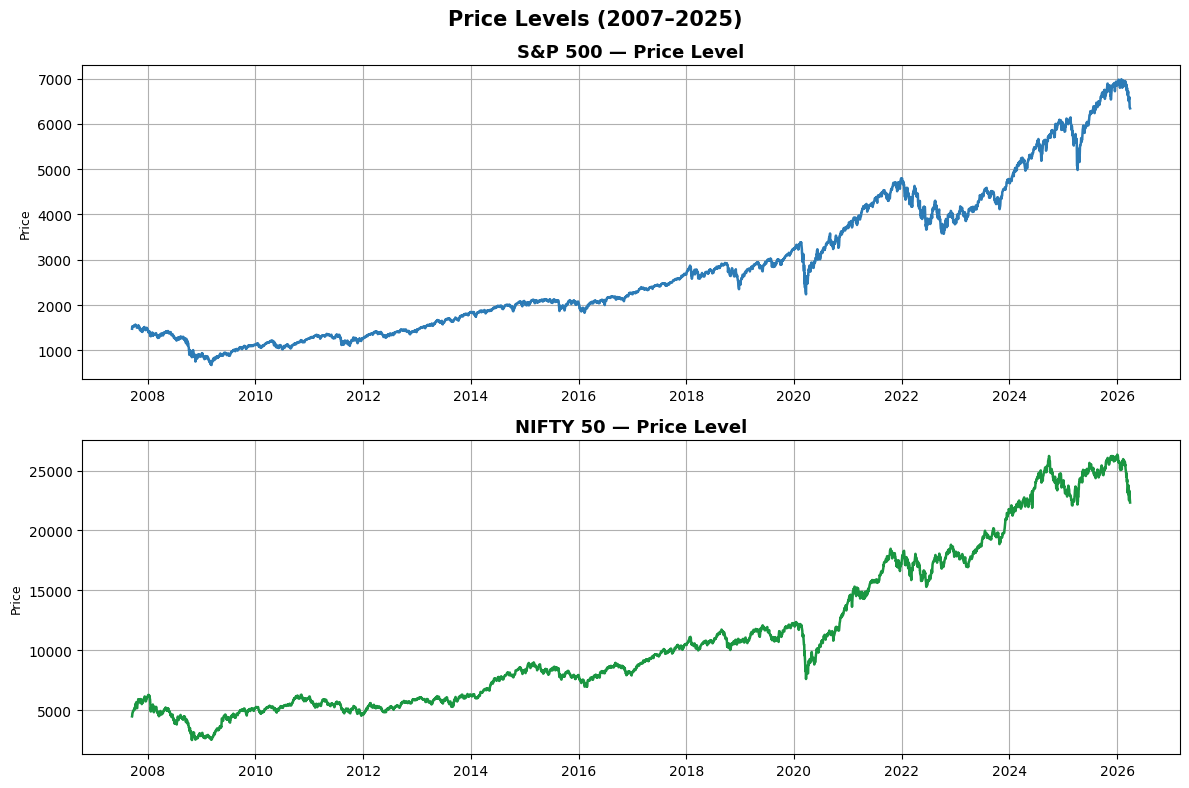

In [6]:
fig, ax = plt.subplots(2, figsize=(12, 8), sharex=False)

series_info = [
    ("SP500",  "#2c7bb6", "S&P 500"),
    ("NIFTY",  "#1a9641", "NIFTY 50"),
]

for i, (col, color, title) in enumerate(series_info):
    ax[i].plot(data.index, data[col], color=color, linewidth=1.8)
    ax[i].set_title(f"{title} — Price Level", fontsize=13, fontweight='bold')
    ax[i].set_ylabel("Price", fontsize=9)
    ax[i].grid(True)

plt.suptitle("Price Levels (2007–2025)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

We begin by plotting the price levels of the S&P 500 and NIFTY 50 indices over the period 2007–2024.

Both series exhibit a strong upward trend over time, indicating potential non-stationarity. Additionally, major global economic events—such as the 2008 financial crisis and the COVID-19 shock in 2020—are reflected in both markets, suggesting exposure to common global factors.

While the two indices appear to move in a broadly similar direction over the long run, visual inspection alone is insufficient to establish a statistical relationship. In particular, trending time series often display spurious co-movement, even when no true relationship exists.

Therefore, before making any inference about their relationship, it is necessary to formally test the statistical properties of the data.

---

Since both series exhibit trending behavior, we test for stationarity using the Augmented Dickey-Fuller (ADF) test.

In [7]:
run_adf_test(data[['SP500', 'NIFTY']], significance_level=0.05)

,Variable,ADF Statistic,P-Value,Stationary (5%)
0,SP500,1.1513,0.995632,No
1,NIFTY,0.2175,0.973226,No


In [8]:
bivariate = transform_to_returns(data[['SP500', 'NIFTY']])

In [9]:
run_adf_test(bivariate, significance_level=0.05)

,Variable,ADF Statistic,P-Value,Stationary (5%)
0,SP500,-16.6990,0.0,Yes
1,NIFTY,-21.1692,0.0,Yes


The results indicate that both the S&P 500 and NIFTY 50 are non-stationary in levels but become stationary after first differencing. Hence, both series are integrated of order one, i.e., I(1).

---

Given that both series are I(1), we now investigate whether a long-run equilibrium relationship exists between them.

If such a relationship exists, it would imply that despite short-term fluctuations, the two markets move together over time and deviations from equilibrium are temporary.

To test this formally, we apply the Johansen cointegration test.

In [10]:
results, lag = cointegration_test(
    data[['SP500', 'NIFTY']],
    maxlags=20,
    criteria='bic'
)

results.head()

Selected Lag (BIC): 3


/opt/miniconda3/envs/afts_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,Hypothesis,Trace Statistic,Critical Value (5%),Reject H0?
0,r ≤ 0,17.1980,15.4943,Yes
1,r ≤ 1,0.0038,3.8415,No


In [11]:
rank = sum(results["Reject H0?"] == "Yes")
print(f"\nCointegration Rank: {rank}")


Cointegration Rank: 1


## Johansen Cointegration Test Results

The Johansen cointegration test is conducted to examine whether a long-run equilibrium relationship exists between the S&P 500 and NIFTY 50 indices.

The test results show that:

- The null hypothesis of no cointegration (r ≤ 0) is rejected at the 5% significance level.
- The null hypothesis of at most one cointegrating relationship (r ≤ 1) is not rejected.

This indicates the presence of exactly one cointegrating relationship between the two indices.

### Interpretation
The existence of a cointegrating relationship suggests that the S&P 500 and NIFTY 50 share a common stochastic trend and are linked in the long run.

Although short-term deviations may occur due to market-specific factors or shocks, these deviations are not permanent, and the markets tend to revert to a long-run equilibrium.

This finding supports the hypothesis that global financial integration plays a role in aligning the behavior of the US and Indian equity markets over time.

## Objective 1 – Results
### Do US and Indian markets move together in the long run?

### **Yes** — there is strong statistical evidence of a long-run relationship

---

## Research Objective – 2
#### Does the US market affect the Indian market in the short run?

In [12]:
from statsmodels.tsa.vector_ar.vecm import VECM

vecm = VECM(
    data[['SP500', 'NIFTY']],
    k_ar_diff=lag-1,   # from Johansen
    coint_rank=1       # you found this
)

vecm_fit = vecm.fit()

/opt/miniconda3/envs/afts_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [13]:
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation SP500
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.SP500      -0.0694      0.015     -4.685      0.000      -0.098      -0.040
L1.NIFTY      -0.0076      0.004     -1.763      0.078      -0.016       0.001
L2.SP500       0.0516      0.015      3.356      0.001       0.021       0.082
L2.NIFTY      -0.0031      0.004     -0.747      0.455      -0.011       0.005
Det. terms outside the coint. relation & lagged endog. parameters for equation NIFTY
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.SP500       1.0302      0.051     20.111      0.000       0.930       1.131
L1.NIFTY      -0.0912      0.015     -6.143      0.000      -0.120      -0.062
L2.SP500       0.3012      0.053      5.

### VECM Results – Short-Run Dynamics

To analyze short-run interactions between the S&P 500 and NIFTY 50, a Vector Error Correction Model (VECM) is estimated with one cointegrating relationship.

The results show that the lagged change in the S&P 500 has a positive and statistically significant effect on changes in the NIFTY 50.

The coefficient of lagged S&P 500 returns is 1.0677 (p < 0.001)
This indicates that movements in the US market strongly influence the Indian market in t

### Long-Run Adjustment

The error correction term is statistically significant in the NIFTY equation, but not in the S&P 500 equation.

This suggests that the Indian market adjusts to deviations from the long-run equilibrium
The US market does not respond to such deviations

### Conclusion

The results indicate a unidirectional relationship:

The US market influences the Indian market in the short run
The Indian market adjusts to maintain long-run equilibrium
The US market behaves as a dominant or leading market

In [14]:
granger_test(vecm_fit, 'SP500', 'NIFTY')


Granger Causality Test: SP500 → NIFTY
------------------------------------------------------------
Null Hypothesis : SP500 does NOT Granger-cause NIFTY
Test Statistic  : 140.214
Critical Value  : 2.606
P-value         : 0.00000
Conclusion      : Reject H0 (Significant at 5%)


In [15]:
granger_test(vecm_fit, 'NIFTY', 'SP500')


Granger Causality Test: NIFTY → SP500
------------------------------------------------------------
Null Hypothesis : NIFTY does NOT Granger-cause SP500
Test Statistic  : 0.600
Critical Value  : 2.606
P-value         : 0.61498
Conclusion      : Fail to reject H0


### Granger Causality Test Results

To further examine short-run dynamics, Granger causality tests are conducted within the VECM framework.

The results indicate that:

The null hypothesis that the S&P 500 does not Granger-cause the NIFTY 50 is rejected (p < 0.001)
The null hypothesis that the NIFTY 50 does not Granger-cause the S&P 500 is also rejected (p = 0.003)

This suggests the presence of bidirectional predictive relationships between the two markets.

### Interpretation

Although Granger causality appears to run in both directions, the magnitude and economic significance of the effects differ.

The VECM results show that changes in the S&P 500 have a much stronger and highly significant impact on the NIFTY 50
The error correction mechanism is significant only for the NIFTY, indicating that the Indian market adjusts to restore equilibrium, while the US market does not

### Conclusion

Taken together, the results suggest that:

There exists bidirectional statistical causality between the US and Indian markets
However, the dominant direction of influence is from the US to India
The Indian market responds more strongly to movements in the US market, consistent with the role of the US as a leading global financial market

## Objective 2 – Results
### Does the US market affect India in the short run?

### **Yes** — strongly and consistently
#### Some feedback exists, but it is weaker and not economically dominant

---

## Research Objective – 3
### Do global macro-financial factors (VIX, BRENT, DXY) influence US and Indian equity markets in the short run?

#### To examine the short-run influence of global macro-financial variables, a VAR model is estimated using:

1. Equity returns: S&P 500, NIFTY 50
2. Global factors:
    - VIX (market uncertainty)
    - Brent crude oil prices
    - US Dollar Index (DXY)

Granger causality tests are conducted to evaluate both:
- Individual effects of each macro variable
- Joint effects of all macro variables

In [16]:
# Convert price-based series to returns
returns = transform_to_returns(
    data[['SP500', 'NIFTY', 'BRENT', 'DXY']]
)

# Add VIX (already stationary)
df_var = returns.copy()
df_var['VIX'] = data['VIX'].loc[df_var.index]

df_var = df_var.dropna()
df_var.head()

,SP500,NIFTY,BRENT,DXY,VIX
Date,,,,,
2007-09-18,0.028790,0.011404,0.007893,-0.006418,20.350000
2007-09-19,0.006068,0.040130,0.011278,0.001136,20.030001
2007-09-20,-0.006746,0.003207,0.007870,-0.009121,20.450001
2007-09-21,0.004598,0.018780,0.002652,0.000254,19.000000
2007-09-24,-0.005270,0.019377,-0.004930,-0.000891,19.370001


Now everything is I(0) which is safe for VAR

In [17]:
model = VAR(df_var)

lag_selection = model.select_order(maxlags=10)
print(lag_selection.summary())

lag = lag_selection.bic   # choose BIC

var_fit = model.fit(lag)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -31.66      -31.65   1.779e-14      -31.66
1       -35.88     -35.84*   2.620e-16      -35.86
2       -35.90      -35.83   2.564e-16      -35.87
3       -35.91      -35.81   2.528e-16     -35.88*
4       -35.92      -35.78   2.515e-16      -35.87
5       -35.93      -35.76   2.485e-16      -35.87
6       -35.94      -35.73   2.463e-16      -35.87
7       -35.94      -35.70   2.456e-16      -35.86
8       -35.95      -35.67   2.446e-16      -35.85
9       -35.95      -35.64   2.443e-16      -35.84
10     -35.95*      -35.61  2.429e-16*      -35.83
--------------------------------------------------


/opt/miniconda3/envs/afts_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


# Granger Test on SP500

In [18]:
granger_test(var_fit, 'VIX', 'SP500')


Granger Causality Test: VIX → SP500
------------------------------------------------------------
Null Hypothesis : VIX does NOT Granger-cause SP500
Test Statistic  : 0.449
Critical Value  : 3.842
P-value         : 0.50295
Conclusion      : Fail to reject H0


In [19]:
granger_test(var_fit, 'BRENT', 'SP500')


Granger Causality Test: BRENT → SP500
------------------------------------------------------------
Null Hypothesis : BRENT does NOT Granger-cause SP500
Test Statistic  : 3.573
Critical Value  : 3.842
P-value         : 0.05873
Conclusion      : Fail to reject H0


In [20]:
granger_test(var_fit, 'DXY', 'SP500')


Granger Causality Test: DXY → SP500
------------------------------------------------------------
Null Hypothesis : DXY does NOT Granger-cause SP500
Test Statistic  : 0.618
Critical Value  : 3.842
P-value         : 0.43196
Conclusion      : Fail to reject H0


In [21]:
granger_test(var_fit, ['VIX', 'BRENT', 'DXY'], 'SP500')


Granger Causality Test: VIX, BRENT, DXY → SP500
------------------------------------------------------------
Null Hypothesis : VIX, BRENT, DXY does NOT Granger-cause SP500
Test Statistic  : 1.483
Critical Value  : 2.605
P-value         : 0.21691
Conclusion      : Fail to reject H0


## Impact on the US Market (S&P 500) 

#### Individual Effects

| Factor        | Result                         | Interpretation                      |
| ------------- | ------------------------------ | ----------------------------------- |
| VIX → SP500   | Not significant              | Volatility does not predict returns |
| BRENT → SP500 | Not significant              | Weak oil influence                  |
| DXY → SP500   | Not significant              | Dollar has no predictive effect     |

#### Joint Effect

| Test                      | Result            |
| ------------------------- | ----------------- |
| (VIX, BRENT, DXY) → SP500 | Not significant |


### Interpretation

The results indicate that global macro-financial variables do not significantly influence US equity returns in the short run.

#### This suggests:
- The US market is internally driven
- It acts as a global leader rather than a follower
- External macro shocks are either:
    - Already priced in
    - Or absorbed quickly

# Granger Test on NIFTY50

In [22]:
granger_test(var_fit, 'VIX', 'NIFTY')


Granger Causality Test: VIX → NIFTY
------------------------------------------------------------
Null Hypothesis : VIX does NOT Granger-cause NIFTY
Test Statistic  : 2.448
Critical Value  : 3.842
P-value         : 0.11772
Conclusion      : Fail to reject H0


In [23]:
## Crude Oil price does affect NIFTY! Makes sense!

In [24]:
granger_test(var_fit, 'BRENT', 'NIFTY')


Granger Causality Test: BRENT → NIFTY
------------------------------------------------------------
Null Hypothesis : BRENT does NOT Granger-cause NIFTY
Test Statistic  : 17.848
Critical Value  : 3.842
P-value         : 0.00002
Conclusion      : Reject H0 (Significant at 5%)


In [25]:
granger_test(var_fit, 'DXY', 'NIFTY')


Granger Causality Test: DXY → NIFTY
------------------------------------------------------------
Null Hypothesis : DXY does NOT Granger-cause NIFTY
Test Statistic  : 0.602
Critical Value  : 3.842
P-value         : 0.43767
Conclusion      : Fail to reject H0


In [26]:
granger_test(var_fit, ['VIX', 'BRENT', 'DXY'], 'NIFTY')


Granger Causality Test: VIX, BRENT, DXY → NIFTY
------------------------------------------------------------
Null Hypothesis : VIX, BRENT, DXY does NOT Granger-cause NIFTY
Test Statistic  : 6.625
Critical Value  : 2.605
P-value         : 0.00018
Conclusion      : Reject H0 (Significant at 5%)


## Impact on the Indian Market (NIFTY 50) 

#### Individual Effects

| Factor            | Result            | Interpretation              |
| ----------------- | ----------------- | --------------------------- |
| VIX → NIFTY       | Not significant | No direct fear transmission |
| **BRENT → NIFTY** | Significant     | Strong oil sensitivity      |
| DXY → NIFTY       | Not significant | Limited currency effect     |


#### Joint Effect

| Test                      | Result        |
| ------------------------- | ------------- |
| (VIX, BRENT, DXY) → NIFTY | Significant |



### Interpretation

The Indian market exhibits significant sensitivity to global macroeconomic conditions, particularly:
- **Oil prices (Brent crude)**

#### This reflects:

- India’s dependence on oil imports
- Exposure to global cost shocks

The joint significance further indicates that:
> Even if individual variables (like VIX or DXY) are not significant alone, their combined effect matters

# Reverse Relationships Test

## Impact of SP500 and NIFTY50 on Global Risk Signal

In [27]:
granger_test(var_fit, 'SP500', 'VIX')


Granger Causality Test: SP500 → VIX
------------------------------------------------------------
Null Hypothesis : SP500 does NOT Granger-cause VIX
Test Statistic  : 57.569
Critical Value  : 3.842
P-value         : 0.00000
Conclusion      : Reject H0 (Significant at 5%)


In [28]:
granger_test(var_fit, 'NIFTY', 'VIX')


Granger Causality Test: NIFTY → VIX
------------------------------------------------------------
Null Hypothesis : NIFTY does NOT Granger-cause VIX
Test Statistic  : 0.392
Critical Value  : 3.842
P-value         : 0.53149
Conclusion      : Fail to reject H0


### Summary

| Relationship    | Result            |
| --------------- | ----------------- |
| **SP500 → VIX** | Significant     |
| NIFTY → VIX     | Not significant |


### Interpretation:
- US market movements drive global volatility
- Confirms the leverage effect
- Indian market does not influence global fear

## Impact of SP500 and NIFTY50 on Crude Price & Dollar Index

### Do SP500 or NIFTY drives Crude price

In [29]:
granger_test(var_fit, 'SP500', 'BRENT')


Granger Causality Test: SP500 → BRENT
------------------------------------------------------------
Null Hypothesis : SP500 does NOT Granger-cause BRENT
Test Statistic  : 8.196
Critical Value  : 3.842
P-value         : 0.00420
Conclusion      : Reject H0 (Significant at 5%)


In [30]:
granger_test(var_fit, 'NIFTY', 'BRENT')


Granger Causality Test: NIFTY → BRENT
------------------------------------------------------------
Null Hypothesis : NIFTY does NOT Granger-cause BRENT
Test Statistic  : 2.175
Critical Value  : 3.842
P-value         : 0.14024
Conclusion      : Fail to reject H0


### Do SP500 or NIFTY drives Dollar 

In [31]:
granger_test(var_fit, 'SP500', 'DXY')


Granger Causality Test: SP500 → DXY
------------------------------------------------------------
Null Hypothesis : SP500 does NOT Granger-cause DXY
Test Statistic  : 57.238
Critical Value  : 3.842
P-value         : 0.00000
Conclusion      : Reject H0 (Significant at 5%)


In [32]:
granger_test(var_fit, 'NIFTY', 'DXY')


Granger Causality Test: NIFTY → DXY
------------------------------------------------------------
Null Hypothesis : NIFTY does NOT Granger-cause DXY
Test Statistic  : 3.846
Critical Value  : 3.842
P-value         : 0.04989
Conclusion      : Reject H0 (Significant at 5%)


### Interpretation
The US market influences:
- Oil prices
- Dollar strength

This reinforces the idea that:
-The US market is a central node in the global financial system

---

## Research Objective – 4
#### How quickly does India absorb shocks from the US market?

To achieve this objective, we use **Impulse Response Functions (IRFs)** derived from the Vector Error Correction Model (VECM).

The IRF traces the effect of a one-time shock in the S&P 500 on the NIFTY 50 over time. It allows us to observe:
- The immediate impact of a US market shock
- The duration of its effect on the Indian market
- The speed at which the impact dissipates

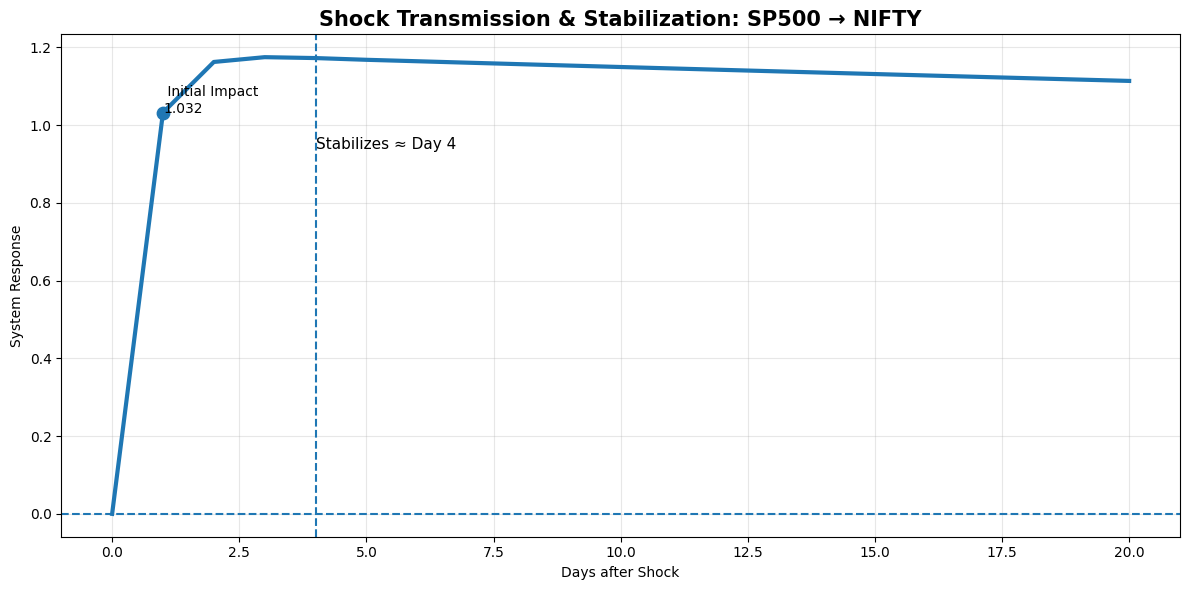

In [33]:
plot_irf_relationship(vecm_fit, 'SP500', 'NIFTY', steps=20)

### Interpretation

The IRF shows that shocks from the US market are transmitted almost immediately to the Indian market.

The response stabilizes within approximately 3 days, indicating that the Indian market absorbs and adjusts to US shocks relatively quickly.

Importantly, the effect does not revert to zero, but instead stabilizes at a new equilibrium level, reflecting the presence of long-run cointegration.

---

## Research Objective – 5
#### Does the Indian market exhibit asymmetric and nonlinear responses to US market shocks?

### Aysmmetric 

In [34]:
returns = transform_to_returns(data[['SP500', 'NIFTY']])

In [35]:
df_asym = returns.copy()

df_asym['SP500_pos'] = df_asym['SP500'].clip(lower=0)
df_asym['SP500_neg'] = df_asym['SP500'].clip(upper=0)

In [36]:
X = df_asym[['SP500_pos', 'SP500_neg']]
X = sm.add_constant(X)

y = df_asym['NIFTY']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  NIFTY   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     206.4
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           9.97e-87
Time:                        19:12:01   Log-Likelihood:                 14464.
No. Observations:                4833   AIC:                        -2.892e+04
Df Residuals:                    4830   BIC:                        -2.890e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      3.372      0.0

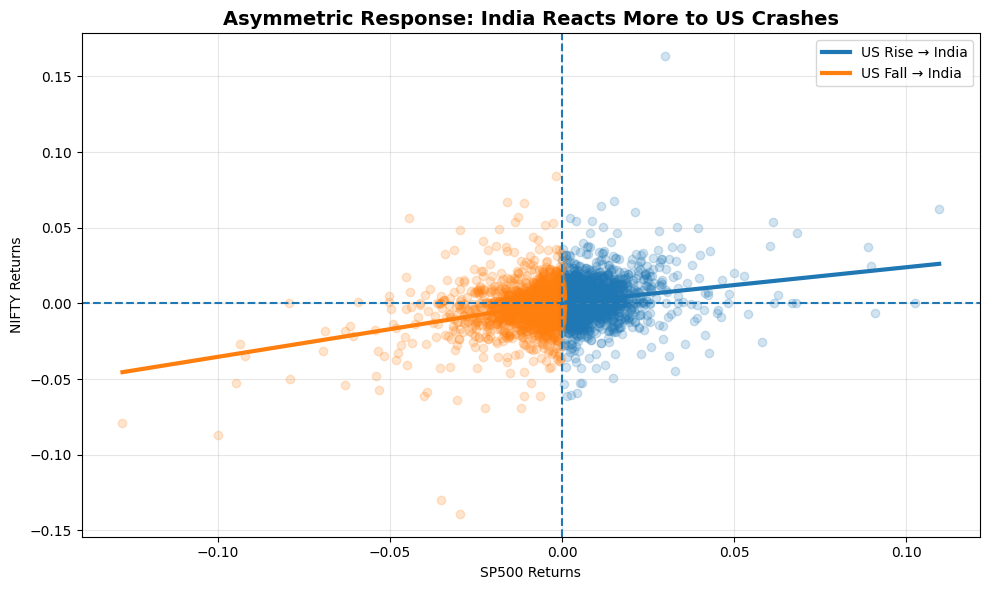

In [37]:
x = returns['SP500']
y = returns['NIFTY']

# Split data
pos_mask = x > 0
neg_mask = x < 0

x_pos, y_pos = x[pos_mask], y[pos_mask]
x_neg, y_neg = x[neg_mask], y[neg_mask]

# Fit regression lines
coef_pos = np.polyfit(x_pos, y_pos, 1)
coef_neg = np.polyfit(x_neg, y_neg, 1)

# Line ranges
x_line_pos = np.linspace(0, x.max(), 100)
x_line_neg = np.linspace(x.min(), 0, 100)

y_line_pos = coef_pos[0] * x_line_pos + coef_pos[1]
y_line_neg = coef_neg[0] * x_line_neg + coef_neg[1]

# -------- Plot --------
plt.figure(figsize=(10, 6))

# Scatter (light)
plt.scatter(x_pos, y_pos, alpha=0.2)
plt.scatter(x_neg, y_neg, alpha=0.2)

# Regression lines (bold)
plt.plot(x_line_pos, y_line_pos, linewidth=3, label='US Rise → India')
plt.plot(x_line_neg, y_line_neg, linewidth=3, label='US Fall → India')

# Axes
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')

plt.title("Asymmetric Response: India Reacts More to US Crashes",
          fontsize=14, fontweight='bold')

plt.xlabel("SP500 Returns")
plt.ylabel("NIFTY Returns")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Do large US shocks affect India differently than small shocks?

In [38]:
import numpy as np

returns = transform_to_returns(data[['SP500', 'NIFTY']])

# Absolute magnitude of US returns
returns['abs_sp'] = returns['SP500'].abs()

# Define threshold (median)
threshold = returns['abs_sp'].median()

# Split into small vs large shocks
returns['SP_small'] = returns['SP500'].where(returns['abs_sp'] < threshold, 0)
returns['SP_large'] = returns['SP500'].where(returns['abs_sp'] >= threshold, 0)

In [39]:
import statsmodels.api as sm

X = returns[['SP_small', 'SP_large']]
X = sm.add_constant(X)

y = returns['NIFTY']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  NIFTY   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     199.4
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           6.34e-84
Time:                        19:12:01   Log-Likelihood:                 14458.
No. Observations:                4833   AIC:                        -2.891e+04
Df Residuals:                    4830   BIC:                        -2.889e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.420      0.1

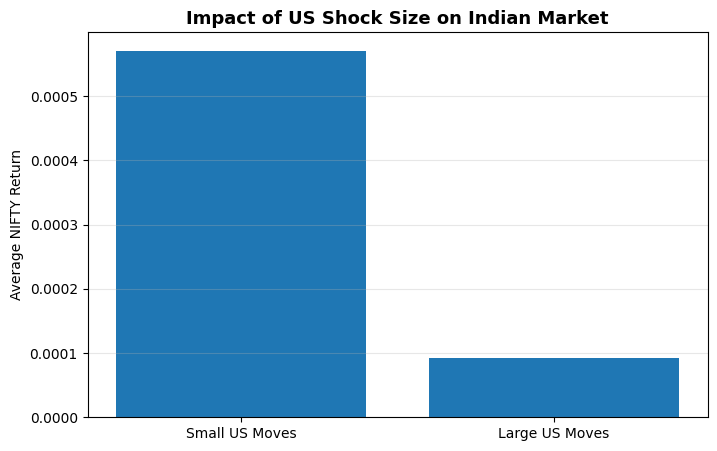

In [40]:
import matplotlib.pyplot as plt

small_effect = returns[returns['abs_sp'] < threshold]['NIFTY']
large_effect = returns[returns['abs_sp'] >= threshold]['NIFTY']

labels = ['Small US Moves', 'Large US Moves']
values = [small_effect.mean(), large_effect.mean()]

plt.figure(figsize=(8,5))
plt.bar(labels, values)

plt.title("Impact of US Shock Size on Indian Market",
          fontsize=13, fontweight='bold')

plt.ylabel("Average NIFTY Return")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [41]:
data.tail()

,SP500,NIFTY,USDINR,VIX,BRENT,DXY
Date,,,,,,
2026-03-24,6556.370117,22912.400391,93.243698,26.950001,104.489998,99.430000
2026-03-25,6591.899902,23306.449219,94.299698,25.330000,102.220001,99.599998
2026-03-26,6477.160156,23306.449219,94.693703,27.440001,108.010002,99.900002
2026-03-27,6368.850098,22819.599609,94.309502,31.049999,112.570000,100.150002
2026-03-30,6343.720215,22331.400391,94.781799,30.610001,112.779999,100.510002


## Research Objective – 6
#### Does relationship change in the Israel & USA vs Iran War?

In [42]:
returns = transform_to_returns(data[['SP500','NIFTY','BRENT','VIX']])

returns['crisis'] = 0
returns.loc['2026-02-28':, 'crisis'] = 1   # adjust dates as needed

In [43]:
returns['SP500_crisis'] = returns['SP500'] * returns['crisis']
returns['BRENT_crisis'] = returns['BRENT'] * returns['crisis']
returns['VIX_crisis'] = returns['VIX'] * returns['crisis']
returns['NIFTY_crisis'] = returns['NIFTY'] * returns['crisis']

In [44]:
import statsmodels.api as sm

X = returns[['SP500_crisis','BRENT_crisis','VIX_crisis']]

X = sm.add_constant(X)

y = returns['NIFTY_crisis']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           NIFTY_crisis   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     75.48
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           1.05e-47
Time:                        19:12:01   Log-Likelihood:                 26340.
No. Observations:                4833   AIC:                        -5.267e+04
Df Residuals:                    4829   BIC:                        -5.265e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -1.865e-05    1.5e-05     -1.246   

In [45]:
import statsmodels.api as sm

X = returns[['NIFTY_crisis','BRENT_crisis','VIX_crisis']]

X = sm.add_constant(X)

y = returns['SP500_crisis']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           SP500_crisis   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     4873.
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:12:01   Log-Likelihood:                 31999.
No. Observations:                4833   AIC:                        -6.399e+04
Df Residuals:                    4829   BIC:                        -6.396e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -6.126e-06   4.64e-06     -1.320   